# Processamento de dados

## 1 - Mapeamento
    1.1 - Criar um dicionario para mapear cada CID unico
    1.2 - Criar um dicionario para mapear cada efeito colateral unico
    1.3 - Criar um dicionario para a traducao do codigo do efeito colateral para seu nome

## 2 - Substituição
    2.1 - Criar um df_treino para poder alterar pelos valores do dicionario
    2.2 - Alterar os valores para os mapeados (cid de 0 a 644 e efeitos de 0 a 1316)

## 3 - Visualização
    3.1 - Visualização do grafo a partir da biblioteca NetworkX

## 4 - Geração das Features
    4.1 - Obter a representação SMILES (texto químico) para cada um dos 645 CIDs únicos via PubChem 
    4.2 - Utilizar o RDKit para converter cada SMILES em um Morgan Fingerprint (vetor binário de 1024 bits)
    4.3 - Construir a Matriz de Nós X: um tensor de tamanho [645, 1024] onde a linha i contém o fingerprint da droga mapeada com o ID i.

## 5 - Criando o Objeto Data
    5.1 Criar o data.x
    5.2 Criar edge_index
    5.3 Criar edge_type

## 6 - Separar as conexões para Treino, Validação e Teste

In [2]:
!pip install torch torch-geometric rdkit pubchempy pandas numpy

In [3]:
import pandas as pd
import numpy as np
import torch
from rdkit import Chem
from rdkit.Chem import AllChem
import pubchempy as pcp

In [4]:
df = pd.read_csv("ChChSe-Decagon_polypharmacy.csv")

In [5]:
df.head(8)

,# STITCH 1,STITCH 2,Polypharmacy Side Effect,Side Effect Name
0,CID000002173,CID000003345,C0151714,hypermagnesemia
1,CID000002173,CID000003345,C0035344,retinopathy of prematurity
2,CID000002173,CID000003345,C0004144,atelectasis
3,CID000002173,CID000003345,C0002063,alkalosis
4,CID000002173,CID000003345,C0004604,Back Ache
5,CID000002173,CID000003345,C0034063,lung edema
6,CID000002173,CID000003345,C0085631,agitated
7,CID000002173,CID000003345,C0013384,abnormal movements


In [6]:
df.dtypes

# STITCH 1                  object
STITCH 2                    object
Polypharmacy Side Effect    object
Side Effect Name            object
dtype: object

In [7]:
drogas_unicas = df[['# STITCH 1', 'STITCH 2']].stack().unique() # utiliza o stack para "colocar a coluna 2 em baixo da 1", tornando-as apenas uma
print(drogas_unicas)

['CID000002173' 'CID000003345' 'CID000005206' 'CID000009433'
 'CID000003929' 'CID000150610' 'CID000001302' 'CID000005064'
 'CID000005267' 'CID000010631' 'CID000004601' 'CID000005376'
 'CID000005090' 'CID000005556' 'CID000004946' 'CID000130881'
 'CID000005391' 'CID000005584' 'CID000002802' 'CID005381226'
 'CID000004212' 'CID000060953' 'CID000000596' 'CID000005726'
 'CID000002522' 'CID000003308' 'CID000003405' 'CID000060795'
 'CID000003446' 'CID004183806' 'CID000004107' 'CID000004917'
 'CID000003161' 'CID000071329' 'CID000003823' 'CID000003911'
 'CID000054454' 'CID000002156' 'CID000004411' 'CID000002907'
 'CID000004192' 'CID000083786' 'CID000003348' 'CID000000838'
 'CID000002617' 'CID000001986' 'CID000006691' 'CID000004920'
 'CID000005478' 'CID006398525' 'CID000003937' 'CID005311048'
 'CID000004158' 'CID000005523' 'CID000003696' 'CID000004112'
 'CID000003899' 'CID000004473' 'CID000000853' 'CID005311181'
 'CID000032797' 'CID000059708' 'CID000003826' 'CID000003143'
 'CID000004736' 'CID0000

In [8]:
quant_drogas_unicas = df[['# STITCH 1', 'STITCH 2']].stack().nunique()
print(quant_drogas_unicas)

645


In [9]:
dict_drogas = {}

for i in range(0, quant_drogas_unicas, 1):
    dict_drogas[drogas_unicas[i]] = i

print(dict_drogas)

{'CID000002173': 0, 'CID000003345': 1, 'CID000005206': 2, 'CID000009433': 3, 'CID000003929': 4, 'CID000150610': 5, 'CID000001302': 6, 'CID000005064': 7, 'CID000005267': 8, 'CID000010631': 9, 'CID000004601': 10, 'CID000005376': 11, 'CID000005090': 12, 'CID000005556': 13, 'CID000004946': 14, 'CID000130881': 15, 'CID000005391': 16, 'CID000005584': 17, 'CID000002802': 18, 'CID005381226': 19, 'CID000004212': 20, 'CID000060953': 21, 'CID000000596': 22, 'CID000005726': 23, 'CID000002522': 24, 'CID000003308': 25, 'CID000003405': 26, 'CID000060795': 27, 'CID000003446': 28, 'CID004183806': 29, 'CID000004107': 30, 'CID000004917': 31, 'CID000003161': 32, 'CID000071329': 33, 'CID000003823': 34, 'CID000003911': 35, 'CID000054454': 36, 'CID000002156': 37, 'CID000004411': 38, 'CID000002907': 39, 'CID000004192': 40, 'CID000083786': 41, 'CID000003348': 42, 'CID000000838': 43, 'CID000002617': 44, 'CID000001986': 45, 'CID000006691': 46, 'CID000004920': 47, 'CID000005478': 48, 'CID006398525': 49, 'CID00000

## 1.2 - Criar um dicionario para mapear cada efeito colateral unico

In [10]:
efeitos_unicos = df['Polypharmacy Side Effect'].unique()
print(efeitos_unicos)

['C0151714' 'C0035344' 'C0004144' ... 'C0025218' 'C0014935' 'C0034494']


In [11]:
quant_efeitos_unicos = df['Polypharmacy Side Effect'].nunique()
print(quant_efeitos_unicos)

1317


In [12]:
dict_efeitos = {}

for i in range(0, quant_efeitos_unicos, 1):
    dict_efeitos[efeitos_unicos[i]] = i

print(dict_efeitos)

{'C0151714': 0, 'C0035344': 1, 'C0004144': 2, 'C0002063': 3, 'C0004604': 4, 'C0034063': 5, 'C0085631': 6, 'C0013384': 7, 'C0001122': 8, 'C0034150': 9, 'C0038000': 10, 'C0003578': 11, 'C0013182': 12, 'C0016204': 13, 'C0242429': 14, 'C0020517': 15, 'C0040034': 16, 'C0428977': 17, 'C0235896': 18, 'C0019080': 19, 'C0158986': 20, 'C0236124': 21, 'C0020456': 22, 'C0031154': 23, 'C0020615': 24, 'C0000731': 25, 'C0018790': 26, 'C0007785': 27, 'C0242184': 28, 'C0013404': 29, 'C0020672': 30, 'C0030446': 31, 'C0243026': 32, 'C0151723': 33, 'C0035220': 34, 'C0035222': 35, 'C0023798': 36, 'C0030790': 37, 'C0003611': 38, 'C0016199': 39, 'C0032326': 40, 'C0003615': 41, 'C0038379': 42, 'C0020598': 43, 'C1145670': 44, 'C0020542': 45, 'C0020440': 46, 'C0021845': 47, 'C0023518': 48, 'C0024115': 49, 'C0020040': 50, 'C0020649': 51, 'C0220981': 52, 'C0010692': 53, 'C0003962': 54, 'C0013274': 55, 'C0039239': 56, 'C0038450': 57, 'C0497247': 58, 'C0398353': 59, 'C0013604': 60, 'C0023895': 61, 'C0151904': 62, '

## 1.3 - Criar um dicionario para a traducao do codigo do efeito colateral para seu nome

In [13]:
dict_efeitos_para_nomes = dict(zip(df['Polypharmacy Side Effect'], df['Side Effect Name']))

print(dict_efeitos_para_nomes)

{'C0151714': 'hypermagnesemia', 'C0035344': 'retinopathy of prematurity', 'C0004144': 'atelectasis', 'C0002063': 'alkalosis', 'C0004604': 'Back Ache', 'C0034063': 'lung edema', 'C0085631': 'agitated', 'C0013384': 'abnormal movements', 'C0001122': 'Acidosis', 'C0034150': 'peliosis', 'C0038000': 'rupture of spleen', 'C0003578': 'Apnea', 'C0013182': 'Drug hypersensitivity', 'C0016204': 'flatulence', 'C0242429': 'pain in throat', 'C0020517': 'allergies', 'C0040034': 'thrombocytopenia', 'C0428977': 'bradycardia', 'C0235896': 'lung infiltration', 'C0019080': 'Bleeding', 'C0158986': 'hypoglycaemia neonatal', 'C0236124': 'Gastrointestinal Obstruction', 'C0020456': 'hyperglycaemia', 'C0031154': 'peritonitis', 'C0020615': 'hypoglycaemia', 'C0000731': 'abdominal distension', 'C0018790': 'asystole', 'C0007785': 'cerebral infarct', 'C0242184': 'hypoxia', 'C0013404': 'Difficulty breathing', 'C0020672': 'decreased body temperature', 'C0030446': 'adynamic ileus', 'C0243026': 'sepsis', 'C0151723': 'Hyp

# 2 - Mapeamento

## 2.1- Criar um df_treino para poder alterar pelos valores do dicionario

In [14]:
df_treino = df.copy()

## 2.2 - Alterar os valores para os mapeados (cid de 0 a 644 e efeitos de 0 a 1316)

In [15]:
df_treino['# STITCH 1'] = df_treino['# STITCH 1'].map(dict_drogas)
df_treino['STITCH 2'] = df_treino['STITCH 2'].map(dict_drogas)
df_treino['Polypharmacy Side Effect'] = df_treino['Polypharmacy Side Effect'].map(dict_efeitos)

In [16]:
df_treino.head(8)

,# STITCH 1,STITCH 2,Polypharmacy Side Effect,Side Effect Name
0,0,1,0,hypermagnesemia
1,0,1,1,retinopathy of prematurity
2,0,1,2,atelectasis
3,0,1,3,alkalosis
4,0,1,4,Back Ache
5,0,1,5,lung edema
6,0,1,6,agitated
7,0,1,7,abnormal movements


In [17]:
# Dropando a tabela dos nomes dos efeitos colaterais, a associação será feita pelo dicionário depois
df_treino = df_treino.drop(columns = ['Side Effect Name'])

df_treino.head(10)

,# STITCH 1,STITCH 2,Polypharmacy Side Effect
0,0,1,0
1,0,1,1
2,0,1,2
3,0,1,3
4,0,1,4
5,0,1,5
6,0,1,6
7,0,1,7
8,0,1,8
9,0,1,9


## 3 - Visualização

### 3.1 - Visualização do grafo a partir da biblioteca NetworkX
    

In [18]:
import networkx as nx
import matplotlib.pyplot as plt

In [19]:
# Para fazer uma visualização do grafo, pegaremos as primeiras 500 linhas do grafo original, pois o jupyter notebook travaria com 4 milhões de arestas
df_amostra = df_treino.sample(250)

# Invertendo o dicionario de droga pra ID (virando id pra droga)
id_droga = {v: k for k, v in dict_drogas.items()}

G = nx.MultiGraph()

# Adicionando as conexões
for _, linha in df_amostra.iterrows():
    droga_a = id_droga[linha['# STITCH 1']]
    droga_b = id_droga[linha['STITCH 2']]

    efeito_id = linha['Polypharmacy Side Effect']

    G.add_edge(droga_a, droga_b, type = efeito_id)

    

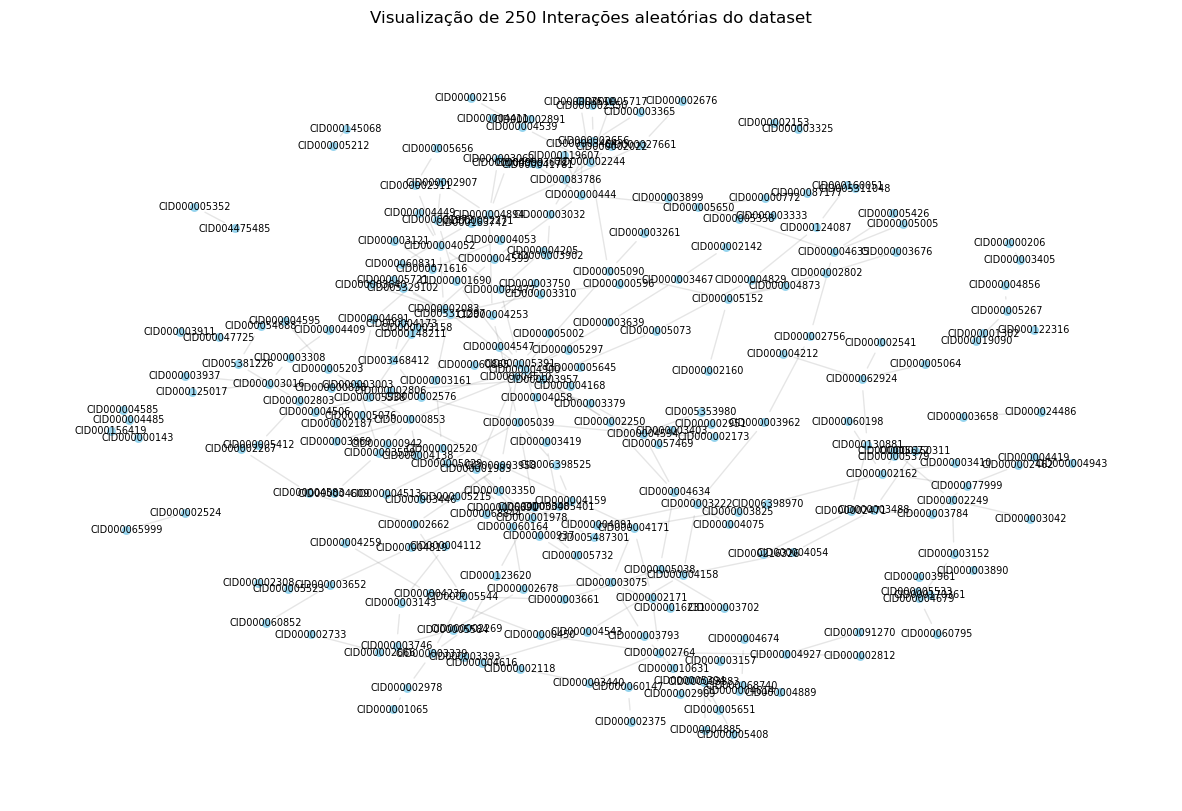

In [20]:
plt.figure(figsize=(15,10))

# Simulando forças de atração e repulsão (ótimo para visualizar clusters)
pos = nx.spring_layout(G, k=0.15, seed=42)

# Desenho dos Nós
nx.draw_networkx_nodes(G, pos, node_size=30, node_color='skyblue', alpha=0.8)

# Desenho das Arestas
nx.draw_networkx_edges(G, pos, alpha=0.2, edge_color='gray')

# Desenho dos Nomes das Drogas
nx.draw_networkx_labels(G, pos, font_size=7, font_family='sans-serif')

plt.title("Visualização de 250 Interações aleatórias do dataset")
plt.axis('off')
plt.show()

## 4 - Geração das Features

### 4.1 - Obter a representação SMILES (texto químico) para cada um dos 645 CIDs únicos via PubChem (pubchempy)

# *ATENÇÃO* | *ATENÇÃO* | *ATENÇÃO* | *ATENÇÃO* 
    só rodar essa aba na primeira vez, pois depois da tradução em smiles ele ja tem um csv com as informações, pra poupar tempo.

In [21]:
import time

dados_lista = []

for i in range(quant_drogas_unicas):

    # Pegando o cid e retirando a parte que não importa
    cid_string = drogas_unicas[i] 
    cid_numero = int(cid_string[3:])

    try: 
        # busca pelo componente
        componente = pcp.Compound.from_cid(cid_numero)
        smiles = componente.smiles

        dados_lista.append({
            'ID' : i,
            'CID' : cid_string,
            'SMILES' : smiles
        })

        if i % 50 == 0:
            print(f'Progresso:. {i}/{quant_drogas_unicas} drogas baixadas')
        elif i == 644:
            print(f'Progresso:. Todas as 645/{quant_drogas_unicas} drogas baixadas!!!')
            

    except Exception as e:
        print(f'Erro no CID {cid_string}: {e}')
        dados_lista.append({'ID': i, 'CID': cid_string, 'SMILES': None})

df_id_cid_smiles = pd.DataFrame(dados_lista)

df_id_cid_smiles.to_csv('id_cid_smiles.csv', index=False)

Progresso:. 0/645 drogas baixadas
Progresso:. 50/645 drogas baixadas
Progresso:. 100/645 drogas baixadas
Progresso:. 150/645 drogas baixadas
Progresso:. 200/645 drogas baixadas
Progresso:. 250/645 drogas baixadas
Progresso:. 300/645 drogas baixadas
Progresso:. 350/645 drogas baixadas
Progresso:. 400/645 drogas baixadas
Progresso:. 450/645 drogas baixadas
Progresso:. 500/645 drogas baixadas
Progresso:. 550/645 drogas baixadas
Progresso:. 600/645 drogas baixadas
Progresso:. Todas as 644/645 drogas baixadas!!!


### 4.2 - Utilizar o RDKit para converter cada SMILES em um Morgan Fingerprint (vetor binário de 1024 bits)


In [39]:
# Para armazenar a Morgan Fingerprint usaremos uma matriz de 645 linhas e 1024 colunas. Cada coluna significa uma propriedade da mólecula (ex: coluna 42 sinaliza um anel de benzeno e 150 uma ligação dupla de oxigênio)
bits = 1024
matriz_mf = np.zeros(((quant_drogas_unicas), bits), dtype=np.float32) # transforma em float 32 pra economizar o espaço de memória
print(matriz_mf)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [40]:
from rdkit.Chem import rdFingerprintGenerator

gerador_morgan = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

# Função de transformação SMILES -> Morgan Fingerprint
def smiles_para_mf(smiles):

    # Transformando o smiles em objeto químico
    mol = Chem.MolFromSmiles(smiles)

    if mol:
        return gerador_morgan.GetFingerprintAsNumPy(mol).astype('float32') 

    # Caso o SMILES seja inválido
    return np.zeros((1024,), dtype=np.float32)

In [41]:
# Loop que percorre o df_id_cid_smiles pra gerar cada fingerprint

for index, linha in df_id_cid_smiles.iterrows():
    id_atual = int(linha['ID'])
    texto_smiles = linha['SMILES']

    mf = smiles_para_mf(texto_smiles)

    matriz_mf[id_atual] = mf

print("Matriz de Morgan Fingerprint criada!")
print(matriz_mf)
    

Matriz de Morgan Fingerprint criada!
[[0. 1. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]]


### 4.3 - Construir a Matriz de Nós X: um tensor de tamanho [645, 1024] onde a linha i contém o fingerprint da droga mapeada com o ID i.

In [42]:
tensor_x = torch.tensor(matriz_mf, dtype=torch.float32)

## 5 - Criando o Objeto Data

    O objeto data contém todos os atributos (componentes) organizados

### 5.1 - Criar o data.x


In [45]:
from torch_geometric.data import Data

x = torch.from_numpy(matriz_mf).to(torch.float32)

### 5.2 - Criar edge_index

In [46]:
# Pegando coluna de IDs
origem = torch.tensor(df_treino['# STITCH 1'].values, dtype=torch.long)
destino = torch.tensor(df_treino['STITCH 2'].values, dtype=torch.long)

# Empilhamos as duas listas para formar o par
edge_index = torch.stack([origem, destino], dim=0)

### 5.3 - Criar edge_type

In [47]:
# Pegamos a coluna onde você mapeou os nomes dos efeitos para IDs numéricos (0 a 1316)
edge_type = torch.tensor(df_treino['Polypharmacy Side Effect'].values, dtype=torch.long)

In [50]:
data = Data(x=x, edge_index=edge_index)
data.edge_type = edge_type

print("CARACTERISTICAS DO GRAFO:")
print(f"Nós (Drogas): {data.num_nodes}")
print(f"Arestas (Conexões): {data.num_edges}")
print(f"Características por Nó: {data.num_node_features}")

CARACTERISTICAS DO GRAFO:
Nós (Drogas): 645
Arestas (Conexões): 4649441
Características por Nó: 1024


## 6 - Separar as conexões para Treino, Validação e Teste

In [52]:
from torch_geometric.transforms import RandomLinkSplit

In [64]:
transform = RandomLinkSplit(
    num_val=0.1, 
    num_test=0.1, 
    is_undirected=True, 
    add_negative_train_samples=False, # Vamos criar os negativos depois no treino
    edge_types=None,
)

train_data, val_data, test_data = transform(data)

n_train = train_data.edge_label_index.size(1)
n_val   = val_data.edge_label_index.size(1)
n_test  = test_data.edge_label_index.size(1)

train_data.edge_label_type = data.edge_type[:n_train]
val_data.edge_label_type   = data.edge_type[n_train : n_train + n_val]
test_data.edge_label_type  = data.edge_type[n_train + n_val : n_train + n_val + n_test]

#    Confirmações

print("=== Tamanhos dos splits ===")
print(f"  Arestas de treino  (edge_index):       {n_train:>8,}")
print(f"  Arestas de val     (edge_label_index): {n_val:>8,}")
print(f"  Arestas de teste   (edge_label_index): {n_test:>8,}")
print(f"  Total esperado:                        {n_train + n_val + n_test:>8,}")
print()

print("=== edge_label_type salvo corretamente? ===")
print(f"  train_data.edge_label_type shape: {train_data.edge_label_type.shape}")
print(f"  val_data.edge_label_type   shape: {val_data.edge_label_type.shape}")
print(f"  test_data.edge_label_type  shape: {test_data.edge_label_type.shape}")
print()

print("=== Tipos de relação são IDs reais (não 0/1)? ===")
print(f"  val_data.edge_label        (deve ser 0s e 1s): {val_data.edge_label[:8].tolist()}")
print(f"  val_data.edge_label_type   (deve ser IDs >1):  {val_data.edge_label_type[:8].tolist()}")
print()

print("=== Cobertura dos tipos de relação ===")
print(f"  Tipos únicos em train: {train_data.edge_label_type.unique().numel()}")
print(f"  Tipos únicos em val:   {val_data.edge_label_type.unique().numel()}")
print(f"  Tipos únicos em test:  {test_data.edge_label_type.unique().numel()}")
print(f"  Total esperado:        1317\n")
print(f"edge_label_index treino: {train_data.edge_label_index.size(1)}")
print(f"edge_label_type  treino: {train_data.edge_label_type.shape}")

=== Tamanhos dos splits ===
  Arestas de treino  (edge_index):       1,756,101
  Arestas de val     (edge_label_index):  219,512
  Arestas de teste   (edge_label_index):  219,512
  Total esperado:                        2,195,125

=== edge_label_type salvo corretamente? ===
  train_data.edge_label_type shape: torch.Size([1756101])
  val_data.edge_label_type   shape: torch.Size([219512])
  test_data.edge_label_type  shape: torch.Size([219512])

=== Tipos de relação são IDs reais (não 0/1)? ===
  val_data.edge_label        (deve ser 0s e 1s): [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
  val_data.edge_label_type   (deve ser IDs >1):  [217, 88, 109, 127, 112, 802, 375, 841]

=== Cobertura dos tipos de relação ===
  Tipos únicos em train: 1313
  Tipos únicos em val:   1284
  Tipos únicos em test:  1288
  Total esperado:        1317

edge_label_index treino: 1756101
edge_label_type  treino: torch.Size([1756101])


C:\Users\Lucas\anaconda3\Lib\site-packages\torch_geometric\transforms\base_transform.py:32: UserWarning: There are not enough negative edges to satisfy the provided sampling ratio. The ratio will be adjusted to 0.00.
  return self.forward(copy.copy(data))


## 7 - Separar para levar o importante para o notebook da GNN

In [65]:
objetos_gnn = {
    'train_data': train_data,
    'val_data': val_data,
    'test_data': test_data,
    'n_nodes': data.num_nodes,
    'n_relations': 1317,
    'in_channels': 1024
}

torch.save(objetos_gnn, 'dados_prontos.pt')

print("Tudo salvo! Agora você pode abrir o Notebook da GNN.")

Tudo salvo! Agora você pode abrir o Notebook da GNN.


# Referências:

- https://networkx.org/documentation/stable/
- https://docs.pubchempy.org/en/latest/
- https://www.rdkit.org/docs/GettingStartedInPython.html
- https://docs.pytorch.org/docs/stable/index.html
- https://www.python.org/
- https://pandas.pydata.org/